# DATA EXPLORATION

## Features

* **CustomerId**—contains random values and has no effect on customer leaving the bank.
* **CreditScore**—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.
* **Country**—a customer’s location can affect their decision to leave the bank.
* **Gender**—it’s interesting to explore whether gender plays a role in a customer leaving the bank.
* **Age**—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.
* **Tenure**—refers to the number of years that the customer has been a client of the bank. 
* **Balance**— refers to the amount of money that a customer has in their account. 
* **product_number**—refers to the number of products that a customer has purchased through the bank.
* **HasCrCard**—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.
* **IsActiveMember**—active customers are less likely to leave the bank.
* **EstimatedSalary**—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
* **Churn**—whether or not the customer left the bank.


## Loading the data

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('../data/raw.csv')
# Display the first few rows of the dataset
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [110]:
print(data.info())
print("_" * 60)
print(data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB
None
____________________________________________________________
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  1000

## Analysis of the data

In [111]:
data["customer_id"].nunique()

10000

There's not repeated values in the customer_id column, so we can be sure that there are no duplicated rows in the dataset.

In [112]:
data["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

The dataset is **not balanced**, since the number of customers who left the bank is much lower than those who stayed. This can be a problem for some machine learning algorithms, which may be biased towards the majority class. Therefore, it’s important to consider techniques for handling imbalanced datasets, such as resampling or using algorithms that are robust to imbalance.

In [113]:
def stacked_plot(df, group, target):
    """
    Function to generate a stacked plots between two variables
    """
    fig, ax = plt.subplots(figsize = (6,4))
    temp_df = (df.groupby([group, target]).size()/df.groupby(group)[target].count()).reset_index().pivot(columns=target, index=group, values=0)
    temp_df.plot(kind='bar', stacked=True, ax = ax, color = ["green", "darkred"])
    ax.xaxis.set_tick_params(rotation=0)
    ax.set_xlabel(group)
    ax.set_ylabel('Churn Percentage')

In [114]:
data["gender"].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

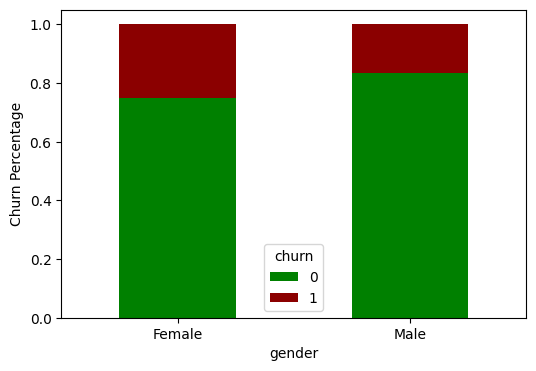

In [115]:
stacked_plot(data,"gender","churn")

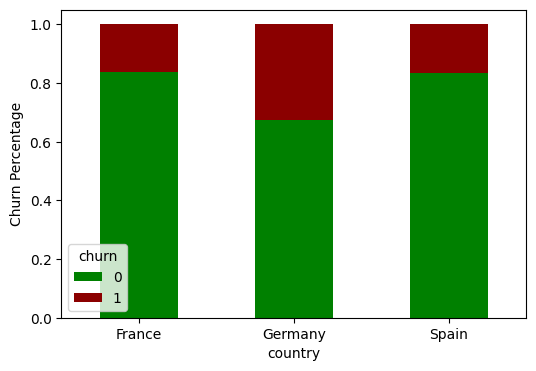

In [116]:
stacked_plot(data,"country","churn")

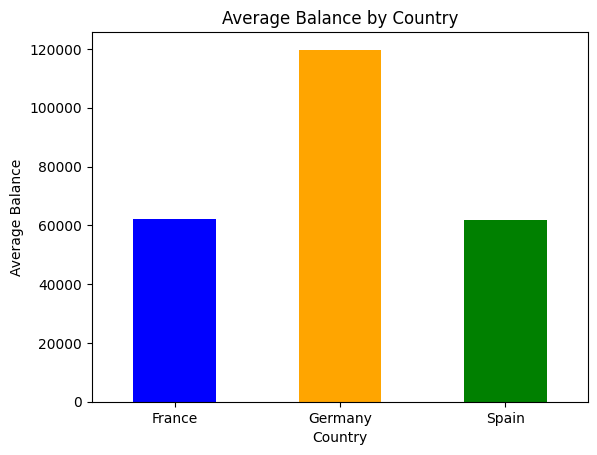

In [117]:
# Plot Balance mean grouped by country 
data.groupby("country")["balance"].mean().plot(kind="bar", color=["blue", "orange", "green"])
plt.xlabel("Country")
plt.ylabel("Average Balance")
plt.title("Average Balance by Country")
plt.xticks(rotation=0)
plt.show()

Spain and France have a similar behavior, with lower churn rates than Germany.

<Axes: xlabel='age', ylabel='Count'>

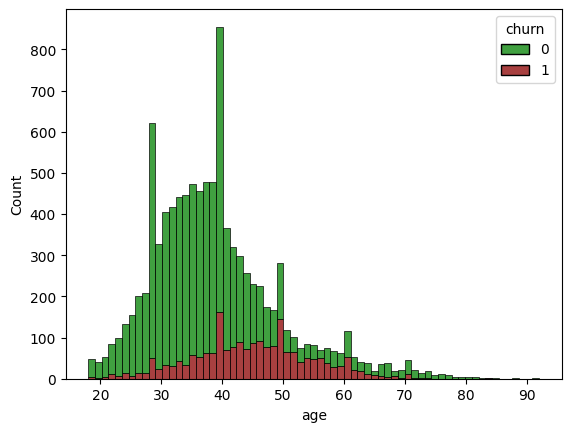

In [118]:
# Age distribution
sns.histplot(data=data, x="age", hue="churn", multiple="stack",palette=["green", "darkred"])

<Axes: xlabel='credit_score', ylabel='age'>

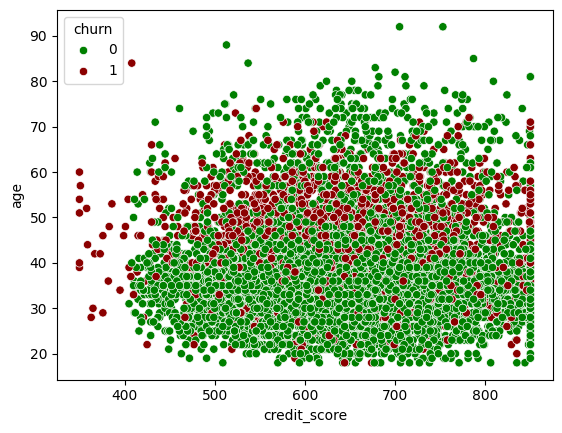

In [119]:
# Age x Credit Score
sns.scatterplot(data=data, x="credit_score", y="age", hue="churn",palette=["green", "darkred"])

<Axes: xlabel='estimated_salary', ylabel='age'>

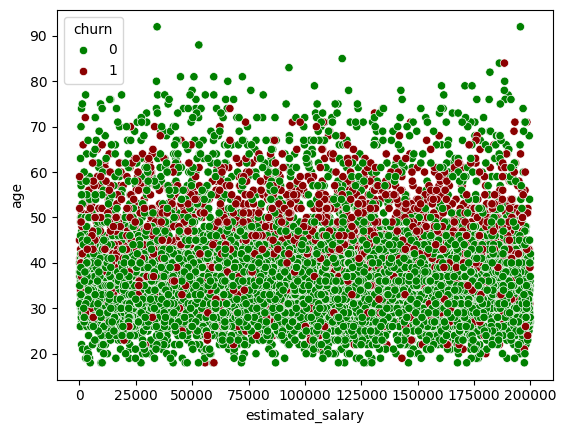

In [120]:
# Age x estimated salary
sns.scatterplot(data=data, x="estimated_salary", y="age", hue="churn",palette=["green", "darkred"])

<Axes: xlabel='balance', ylabel='Count'>

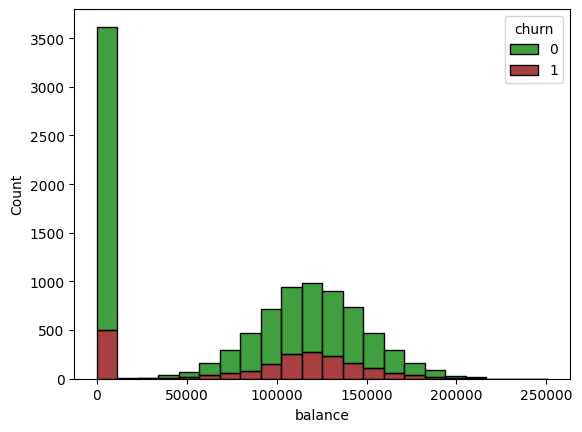

In [121]:
# Balance histogram
sns.histplot(data=data, x="balance", hue="churn", multiple="stack",palette=["green", "darkred"])

We can also see that, there is a higher churn rate among 40-60. Furthermore, there is a higher concentration of customers with 0 balance, so it could be interesting to study this group of customers in more detail.

<Axes: xlabel='products_number', ylabel='Count'>

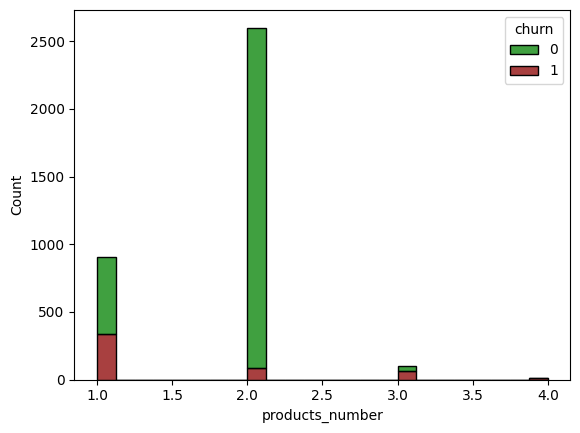

In [122]:
#  x Number of products
sns.histplot(data=data[data["balance"] == 0], x="products_number", hue="churn", multiple="stack",palette=["green", "darkred"])

## Refactoring categorical features and scaling numerical features

In [124]:
def CleanData(df):

    from sklearn.preprocessing import OneHotEncoder
    # Drop customer_id column
    df.drop(columns=["customer_id"], inplace=True)

    # Refactoring categorical features
    encoder = OneHotEncoder(sparse_output=False) 

    # fit_transform now returns a dense array directly
    encoded_features = encoder.fit_transform(df[["gender", "country"]])

    encoded_df = pd.DataFrame(
        encoded_features, 
        columns=encoder.get_feature_names_out()
    )
    # Concatenate the encoded features with the original dataframe
    df = pd.concat([df.drop(columns=["gender", "country"]), encoded_df], axis=1)
    # Scaling numerical features
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    numerical_cols = ["credit_score", "age", "tenure", "balance", "products_number", "estimated_salary"]
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    return df

In [127]:
# Save the cleaned data
data.to_csv('../data/processed.csv', index=False)

## Explore Correlations

In [125]:
data = CleanData(data)

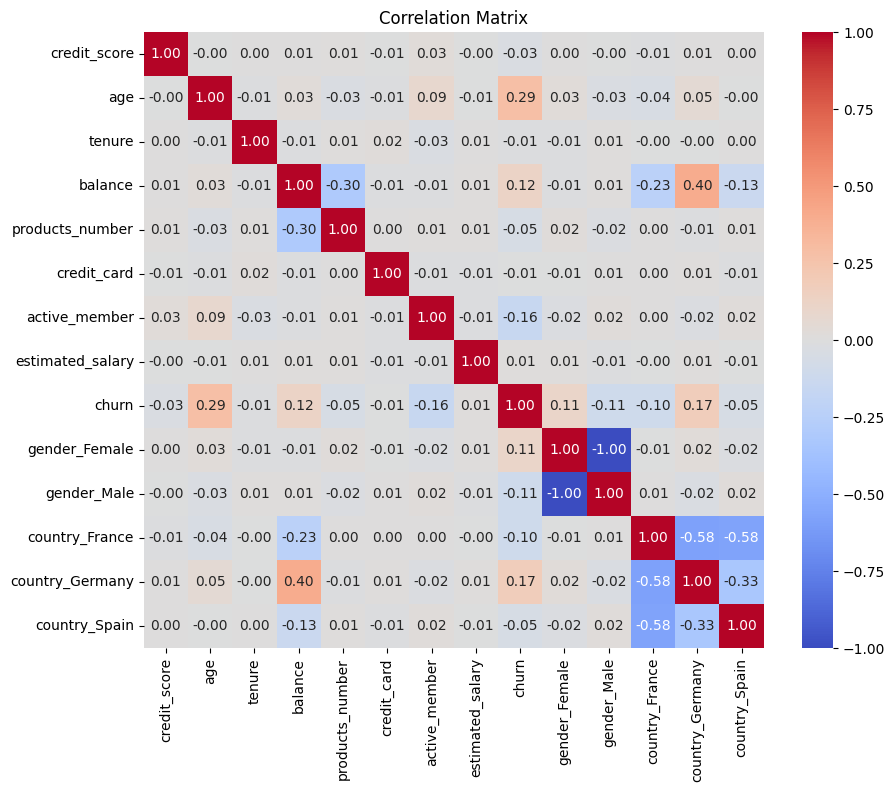

In [126]:
#Correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

There's not risk of muticollinearity between the features, since there are no strong correlations between them. As we could see in the previous section, germany has a higher average balance than spain and france, but this is not a strong correlation, since there are many customers with 0 balance in all three countries. 

When we look at the number of products, we can see that there is a higher churn rate among customers with only one product, which could be an interesting insight to explore further. However, there are no strong correlations between the number of products and other features.
